# 1. Project Introduction

In [1]:
"""
Project: Student Academic Risk Prediction with Machine Learning

Goal:
Build a machine learning model to predict student academic outcomes and identify students risk based on educational data.

Main task:
1. Perform exploratory data analysis
2. Preprocess the dataset
3. Train multiple classification models
4. Evaluate model performance
5. Analyze important factors related to student outcomes

dataset:
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success
"""

'\nProject: Student Academic Risk Prediction with Machine Learning\n\nGoal:\nBuild a machine learning model to predict student academic outcomes and identify students risk based on educational data.\n\nMain task:\n1. Perform exploratory data analysis\n2. Preprocess the dataset\n3. Train multiple classification models\n4. Evaluate model performance\n5. Analyze important factors related to student outcomes\n\ndataset:\nhttps://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier



In [3]:
df = pd.read_csv('../data/raw/data.csv', sep=';')

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
print(df.shape)
print('='*64)
print(df.info())
print('='*64)
print(df.isnull().sum())
print('='*64)
print(df.describe())

(4424, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification        

In [5]:
print(df['Target'].head())
print('='*64)
print(df['Target'].unique())
print('='*64)
print(df['Target'].value_counts())

0     Dropout
1    Graduate
2     Dropout
3    Graduate
4    Graduate
Name: Target, dtype: object
['Dropout' 'Graduate' 'Enrolled']
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [6]:
#将特征和输出拆分
X = df.drop('Target', axis=1)
y = df['Target']

print(X.head())
print('='*64)
print(y.head())
print('='*64)
print('X shape: ', X.shape)
print('y shape: ', y.shape) 

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                         

In [7]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print('Original y: ')
print(y.head())
print('='*64)
print('Encoded y: ')
print(y_encoded[:20])
print('='*64)

print('Class mapping: ')
for i, class_name in enumerate(label_encoder.classes_):
    print(i, '->', class_name)


Original y: 
0     Dropout
1    Graduate
2     Dropout
3    Graduate
4    Graduate
Name: Target, dtype: object
Encoded y: 
[0 2 0 2 2 2 2 0 2 0 2 2 0 2 2 0 1 2 2 1]
Class mapping: 
0 -> Dropout
1 -> Enrolled
2 -> Graduate


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)
print('='*64)
print('='*64)

#value_counts(normalize=True),统计每个类别所占的比例，而不是原始个数
print('Overall distribution: ')
print(pd.Series(y_encoded).value_counts(normalize=True))
print('='*64)
print('Training distribution: ')
print(pd.Series(y_train).value_counts(normalize=True))
print('='*64)
print('Testing distribution: ')
print(pd.Series(y_test).value_counts(normalize=True))

X_train shape:  (3539, 36)
X_test shape:  (885, 36)
y_train shape:  (3539,)
y_test shape:  (885,)
Overall distribution: 
2    0.499322
0    0.321203
1    0.179476
Name: proportion, dtype: float64
Training distribution: 
2    0.499294
0    0.321277
1    0.179429
Name: proportion, dtype: float64
Testing distribution: 
2    0.499435
0    0.320904
1    0.179661
Name: proportion, dtype: float64


In [9]:
#baseline model _ logistic regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [11]:
#prediction
y_pred = log_reg.predict(X_test_scaled)

print('First 10 predictions: ')
print(y_pred[:10])
print('='*64)
print('First 10 true labels: ')
print(y_test[:10])

First 10 predictions: 
[2 2 0 2 2 2 2 2 2 2]
First 10 true labels: 
[2 2 1 2 2 2 2 2 2 2]


In [12]:
#accuracy
acc = accuracy_score(y_test, y_pred)
print('Accuracy: ', acc)

Accuracy:  0.768361581920904


In [13]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.77      0.78       284
           1       0.52      0.33      0.41       159
           2       0.80      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.68       885
weighted avg       0.75      0.77      0.75       885



[[218  29  37]
 [ 43  53  63]
 [ 14  19 409]]


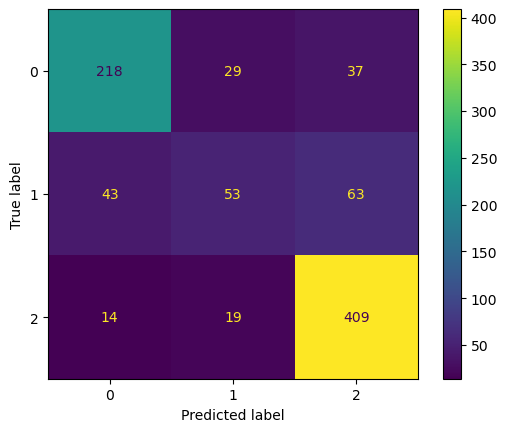

In [14]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [15]:
#randomforestClassifier model
#randomforest一般不需要标准化
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [16]:
#prediction
rf_pred = rf_model.predict(X_test)
print('First 10 RF predictions: ')
print(rf_pred[:10])
print('='*64)
print('First 10 ture labels: ')
print(y_test[:10])
print('='*64)
rf_acc = accuracy_score(y_test, rf_pred)
print('Random Forest Accuracy: ', rf_acc)
print('='*64)
print(classification_report(y_test, rf_pred))
print('='*64)

rf_cm = confusion_matrix(y_test, rf_pred)
print(rf_cm)

First 10 RF predictions: 
[2 2 0 2 2 2 2 2 2 2]
First 10 ture labels: 
[2 2 1 2 2 2 2 2 2 2]
Random Forest Accuracy:  0.7706214689265537
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       284
           1       0.58      0.38      0.46       159
           2       0.79      0.93      0.85       442

    accuracy                           0.77       885
   macro avg       0.73      0.68      0.70       885
weighted avg       0.76      0.77      0.76       885

[[213  22  49]
 [ 37  60  62]
 [ 12  21 409]]


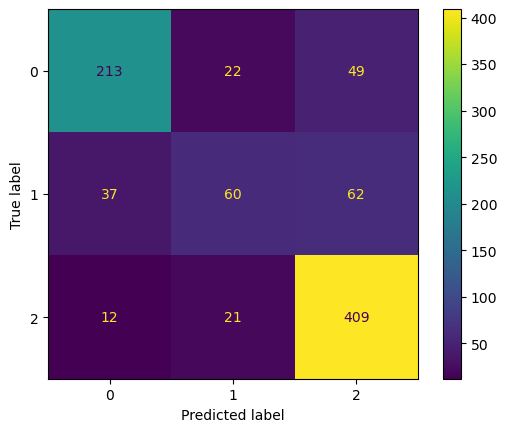

In [17]:
#randomforest confusion matrix display
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.show()

In [18]:
#comparison table
#logistic regression
lr_accuracy = accuracy_score(y_test, y_pred)
lr_macro_p, lr_macro_r, lr_macro_f1, _ = precision_recall_fscore_support(y_test, y_pred,average='macro')
lr_weighted_p, lr_weighted_r, lr_weighted_f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

#random forest
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_macro_p, rf_macro_r, rf_macro_f1, _ = precision_recall_fscore_support(y_test, rf_pred, average='macro')
rf_weighted_p, rf_weighted_r, rf_weighted_f1, _ = precision_recall_fscore_support(y_test, rf_pred, average='weighted')

#table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy],
    'Macro Precision': [lr_macro_p, rf_macro_p],
    'Macro Recall': [lr_macro_r, rf_macro_r],
    'Macro F1': [lr_macro_f1, rf_macro_f1],
    'Weighted F1': [lr_weighted_f1, rf_weighted_f1]
})

comparison_df


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression,0.768362,0.707005,0.675426,0.682601,0.753128
1,Random Forest,0.770621,0.727347,0.684233,0.696182,0.757339


In [19]:
'''
comparison conculusion
random forest slightly outperformed lgistic regression across all major metrics, including accuracy, Macro precision, Macro recall, Macro F1, 
and weighted F1.
Although the performance gap is not large, random forest provides more balanced classification performance across classes, which is especially
important for this project because the target classes are not perfectly balanced.
Therefore, Random Forest is the stronger candidate as the main model at this stage.
'''

'\ncomparison conculusion\nrandom forest slightly outperformed lgistic regression across all major metrics, including accuracy, Macro precision, Macro recall, Macro F1, \nand weighted F1.\nAlthough the performance gap is not large, random forest provides more balanced classification performance across classes, which is especially\nimportant for this project because the target classes are not perfectly balanced.\nTherefore, Random Forest is the stronger candidate as the main model at this stage.\n'

In [20]:
#单独分析类别1

In [21]:
for i, class_name in enumerate(label_encoder.classes_):
    print(i, '->', class_name)

0 -> Dropout
1 -> Enrolled
2 -> Graduate


In [22]:
lr_p, lr_r, lr_f1, lr_support = precision_recall_fscore_support(y_test, y_pred, average=None)
rf_p, rf_r, rf_f1, rf_support = precision_recall_fscore_support(y_test, rf_pred, average=None)

class_comparison_df = pd.DataFrame({
    "Class Label": [0, 1, 2],
    "LR Precision": lr_p,
    "LR Recall": lr_r,
    "LR F1": lr_f1,
    "RF Precision": rf_p,
    "RF Recall": rf_r,
    "RF F1": rf_f1,
    "Support": lr_support
})

class_comparison_df

,Class Label,LR Precision,LR Recall,LR F1,RF Precision,RF Recall,RF F1,Support
0,0,0.792727,0.767606,0.779964,0.812977,0.750000,0.780220,284
1,1,0.524752,0.333333,0.407692,0.582524,0.377358,0.458015,159
2,2,0.803536,0.925339,0.860147,0.786538,0.925339,0.850312,442


In [23]:
class_names = label_encoder.classes_

class_comparison_df["Class Name"] = class_names
class_comparison_df = class_comparison_df[
    ["Class Label", "Class Name", "LR Precision", "LR Recall", "LR F1", "RF Precision", "RF Recall", "RF F1", "Support"]
]
class_comparison_df

,Class Label,Class Name,LR Precision,LR Recall,LR F1,RF Precision,RF Recall,RF F1,Support
0,0,Dropout,0.792727,0.767606,0.779964,0.812977,0.750000,0.780220,284
1,1,Enrolled,0.524752,0.333333,0.407692,0.582524,0.377358,0.458015,159
2,2,Graduate,0.803536,0.925339,0.860147,0.786538,0.925339,0.850312,442


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


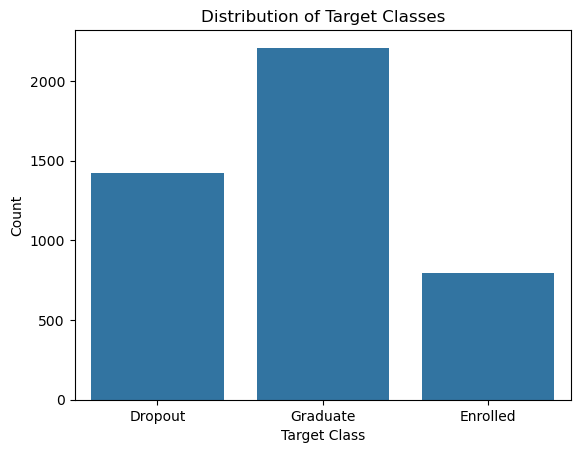

In [24]:
#类别数量可视化
target_counts = df["Target"].value_counts()
print(target_counts)

sns.countplot(x="Target", data = df)
plt.title("Distribution of Target Classes")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()

In [25]:
#分析Enrolled

In [26]:
df.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance\t',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation r

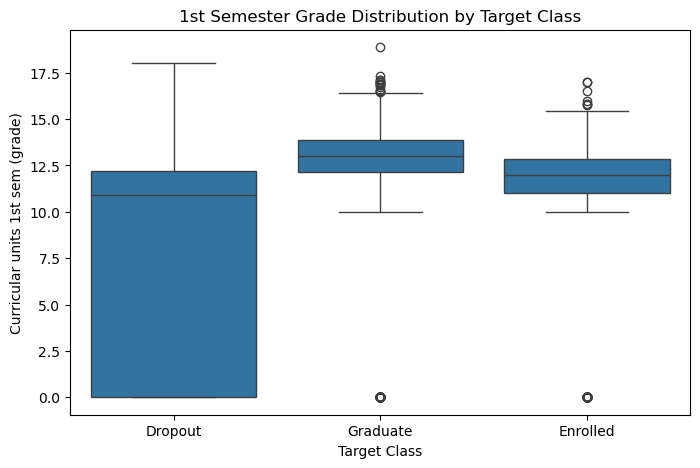

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Target", y="Curricular units 1st sem (grade)", data=df)
plt.title("1st Semester Grade Distribution by Target Class")
plt.xlabel("Target Class")
plt.ylabel("Curricular units 1st sem (grade)")
plt.show()

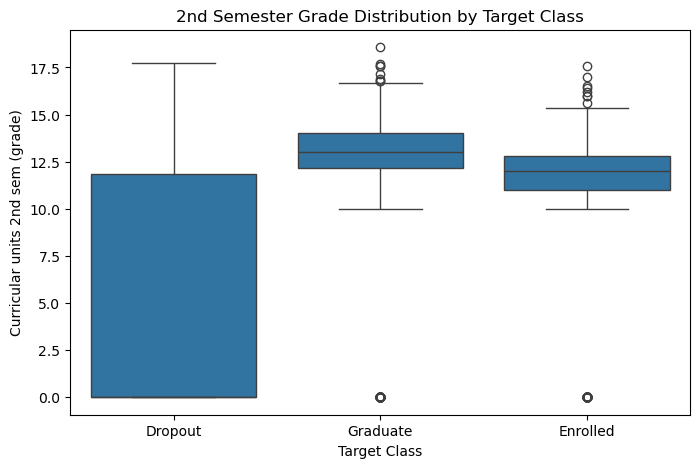

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Target", y="Curricular units 2nd sem (grade)", data=df)
plt.title("2nd Semester Grade Distribution by Target Class")
plt.xlabel("Target Class")
plt.ylabel("Curricular units 2nd sem (grade)")
plt.show()

The Enrolled class appears to be the hardest to predict because its feature distributions overlap substantially with both Dropout and Graduate, especially on semester grade-related variables. This overlap makes the class boundary less distinct and increases the likelihood of misclassification.

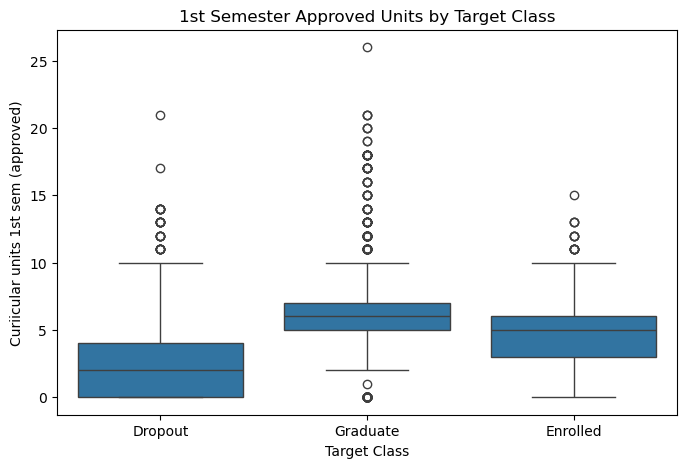

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Target", y="Curricular units 1st sem (approved)", data=df)
plt.title("1st Semester Approved Units by Target Class")
plt.xlabel("Target Class")
plt.ylabel("Curiicular units 1st sem (approved)")
plt.show()

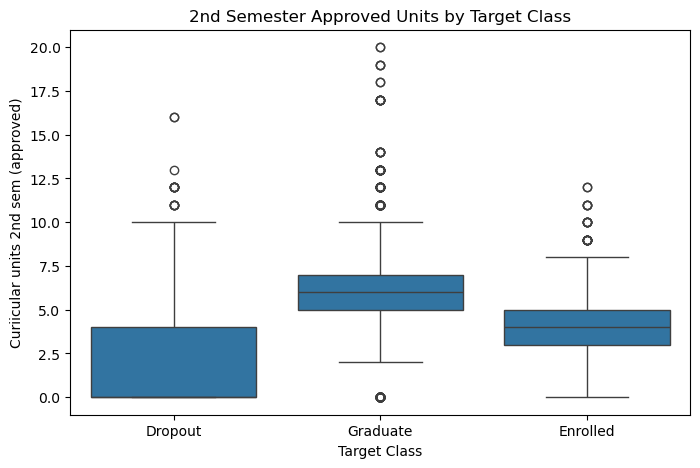

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Target", y="Curricular units 2nd sem (approved)", data=df)
plt.title("2nd Semester Approved Units by Target Class")
plt.xlabel("Target Class")
plt.ylabel("Curiicular units 2nd sem (approved)")
plt.show()

The Enrolled class appears to be the most difficult class to predict.
This difficulty cannot be explained only by its smaller sample size.
From the boxplots of semester grades and approved curricular units,
Enrolled students consistently appear between Dropout and Graduate,
showing a clear "middle-state" pattern.

More importantly, the Enrolled class overlaps substantially with both
Dropout and Graduate on several important academic features.
This overlap suggests that the decision boundary for Enrolled is less distinct,
which increases the chance of misclassification.

In particular, for approved curricular units in the second semester,
Enrolled overlaps less with Graduate but still overlaps strongly with Dropout.
This may indicate that, on some later academic performance features,
Enrolled students are more likely to resemble the risk side than the graduate side.

In [31]:
feature_importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
30,Curricular units 2nd sem (approved),0.142640
31,Curricular units 2nd sem (grade),0.108841
24,Curricular units 1st sem (approved),0.091928
25,Curricular units 1st sem (grade),0.059816
12,Admission grade,0.043891
19,Age at enrollment,0.040325
16,Tuition fees up to date,0.038829
29,Curricular units 2nd sem (evaluations),0.038382
6,Previous qualification (grade),0.037108
23,Curricular units 1st sem (evaluations),0.037058


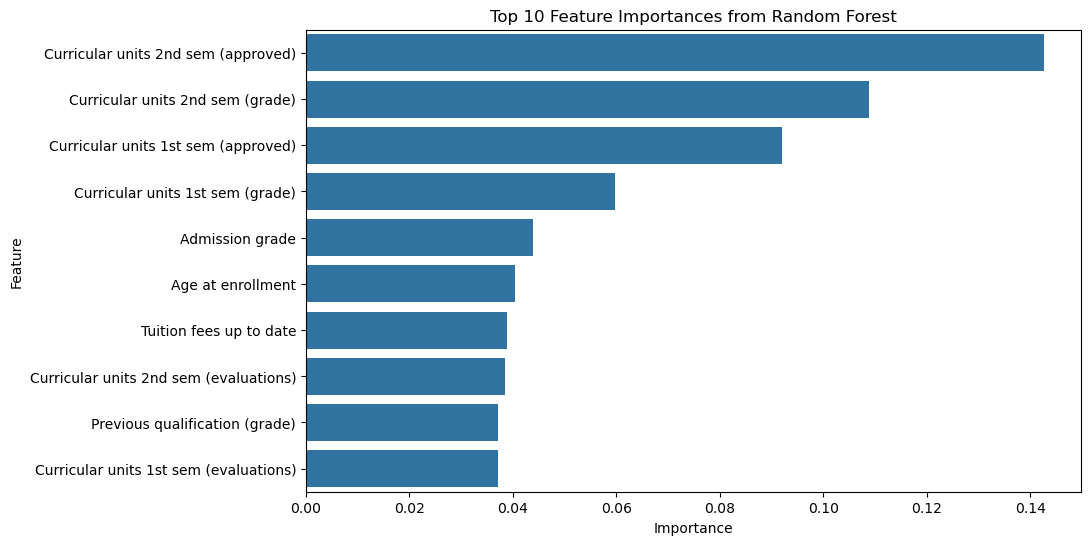

In [34]:
top10_features = importance_df.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_features, x="Importance", y="Feature")
plt.title("Top 10 Feature Importances from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Feature importance interpretation

Random Forest feature importance analysis shows that the most influential variables
are mainly related to academic performance, especially approved curricular units
and semester grades. In particular, the top features include second-semester approved units,
second-semester grades, first-semester approved units, and first-semester grades.

This result is consistent with the earlier boxplot analysis. The same academic features
that the model relies on most are also the features on which the Enrolled class shows
substantial overlap with both Dropout and Graduate.

Therefore, the difficulty in classifying Enrolled is not because these features are unimportant.
Instead, it is because even highly important features do not provide a sufficiently clear
decision boundary for the Enrolled class. This helps explain why both Logistic Regression
and Random Forest struggle more with Enrolled than with the other two classes.